### Goal:
Cluster housing districts by location. We expect to see the shape of California emerge, with specific dense distinct clusters (like Los Angeles or the Bay Area) and "noise" points in rural areas.

#### 1) Importing Necessary Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

#### 2) Loading Data:

In [2]:
data = fetch_california_housing()

In [3]:
X = data.data

In [5]:
X

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]], shape=(20640, 8))

In [6]:
X.shape

(20640, 8)

We focus ONLY on Latitude and Longitude (Columns 6 and 7) for spatial clustering:

In [7]:
X_spatial = X[:, [6,7]]

In [8]:
X_spatial

array([[  37.88, -122.23],
       [  37.86, -122.22],
       [  37.85, -122.24],
       ...,
       [  39.43, -121.22],
       [  39.43, -121.32],
       [  39.37, -121.24]], shape=(20640, 2))

#### 3) Preprocessing:

In [9]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X_spatial)

In [10]:
X_scaled

array([[ 1.05254828, -1.32783522],
       [ 1.04318455, -1.32284391],
       [ 1.03850269, -1.33282653],
       ...,
       [ 1.77823747, -0.8237132 ],
       [ 1.77823747, -0.87362627],
       [ 1.75014627, -0.83369581]], shape=(20640, 2))

#### 4) DBSCAN:


In [42]:
dbscan = DBSCAN(eps= 0.1, min_samples= 10)

In [43]:
labels = dbscan.fit_predict(X_scaled)

In [44]:
labels

array([0, 0, 0, ..., 0, 0, 0], shape=(20640,))

In [45]:
np.unique(labels)

array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

- 'labels' contains the cluster ID for each point.
- -1 indicates "Noise" (outliers).

#### 5) Visualizing DBSCAN Clusters:

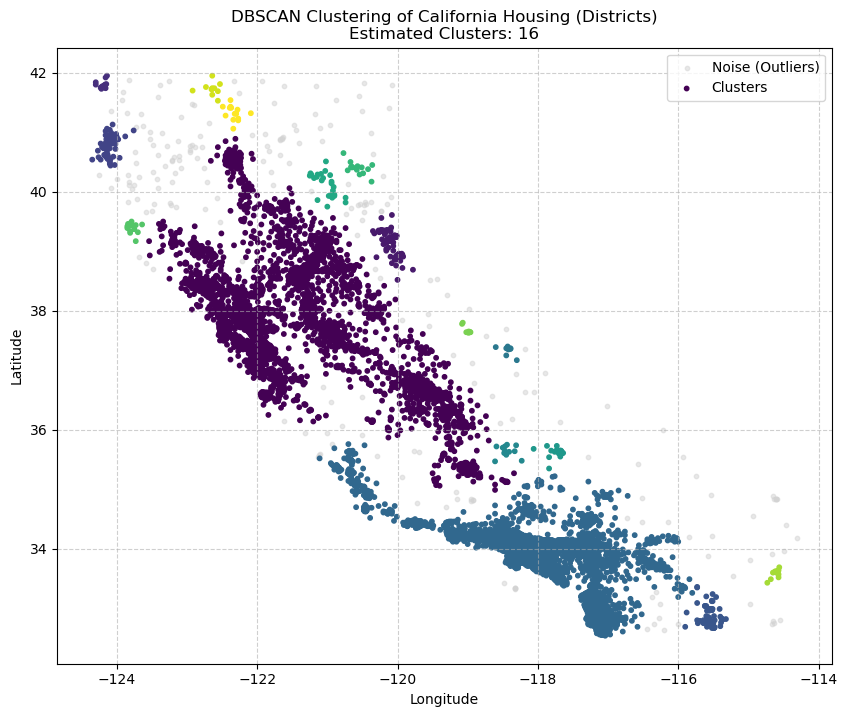

In [46]:
plt.figure(figsize=(10, 8))

# Mask for Outliers (label -1):
noise_mask = (labels == -1)

# Mask for Clustered points (any label != -1):
cluster_mask = (labels != -1)

# Plotting Outliers:
plt.scatter(X_spatial[noise_mask, 1], X_spatial[noise_mask, 0], 
            c='lightgrey', label='Noise (Outliers)', s=10, alpha=0.5)

# Plotting Clustered Points:
plt.scatter(X_spatial[cluster_mask, 1], X_spatial[cluster_mask, 0], 
            c=labels[cluster_mask], cmap='viridis', label='Clusters', s=10)

plt.title(f"DBSCAN Clustering of California Housing (Districts)\nEstimated Clusters: {len(set(labels)) - 1}")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

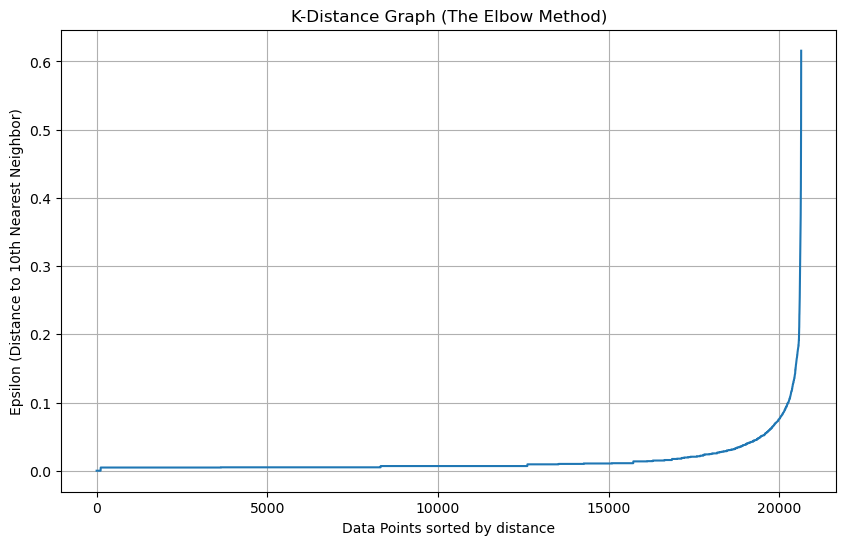

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler

# 1. Load and Scale Data (Same as before)
data = fetch_california_housing()
X_spatial = data.data[:, [6, 7]] # Lat/Lon
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_spatial)

# 2. Calculate Nearest Neighbors
# We use n_neighbors=10 because we used min_samples=10 in the previous example.
# (Rule of thumb: neighbors = min_samples)
neighbors = NearestNeighbors(n_neighbors=10)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# 3. Sort distance values by ascending value
# We only care about the distance to the 10th nearest neighbor (column index 9)
distances = np.sort(distances[:, 9], axis=0)

# 4. Plot
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title("K-Distance Graph (The Elbow Method)")
plt.xlabel("Data Points sorted by distance")
plt.ylabel("Epsilon (Distance to 10th Nearest Neighbor)")
plt.grid(True)
plt.show()

In [49]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Define a range of eps values to test around your "Elbow" found above
eps_values = [0.1, 0.15, 0.2, 0.25, 0.3]
results = []

print(f"{'Epsilon':<10} | {'Clusters':<10} | {'Silhouette Score':<15}")
print("-" * 40)

for eps in eps_values:
    # Train DBSCAN
    db = DBSCAN(eps=eps, min_samples=10)
    labels = db.fit_predict(X_scaled)
    
    # Filter noise for score calculation
    # We only score points that are NOT noise (-1)
    core_mask = labels != -1
    
    # We need at least 2 clusters to calculate a score
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters > 1:
        score = silhouette_score(X_scaled[core_mask], labels[core_mask])
        print(f"{eps:<10} | {n_clusters:<10} | {score:.4f}")
    else:
        print(f"{eps:<10} | {n_clusters:<10} | Not defined")

Epsilon    | Clusters   | Silhouette Score
----------------------------------------
0.1        | 16         | 0.3044
0.15       | 4          | -0.0408
0.2        | 3          | -0.0270
0.25       | 1          | Not defined
0.3        | 1          | Not defined
